# CASE A — both classifiers are correct

The condition applied is that both the prediction obtained with the model trained on the synthetic and real datasets are correct.
Grad-CAM and IG use the **same set of indices**, so figures and metrics are
directly comparable.


## Prerequisites and project structure


`cifar10_utils.py` prevents implicit downloads. If CIFAR-10 is not already
available, set `ALLOW_CIFAR10_DOWNLOAD=1` before loading it, provided an Internet
connection is available.



In [2]:
from pathlib import Path
import sys

# Set an absolute path only if the notebook is not in the project root.
PROJECT_DIR_OVERRIDE = None  


def find_project_dir(start=None):
    required = (
        Path("Models/ImageClassifiers/resnet.py"),
        Path("scripts/classifier_part/cifar10_utils.py"),
        Path("scripts/classifier_part/xai_metrics.py"),
    )
    if PROJECT_DIR_OVERRIDE is not None:
        candidate = Path(PROJECT_DIR_OVERRIDE).expanduser().resolve()
        if all((candidate / item).exists() for item in required):
            return candidate
        raise FileNotFoundError(
            f"PROJECT_DIR_OVERRIDE does not contain all required files: {candidate}"
        )

    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if all((candidate / item).exists() for item in required):
            return candidate
    raise FileNotFoundError(
        "Project root not found. Place the notebook, cifar10_utils.py, and "
        "xai_metrics.py in the root or set PROJECT_DIR_OVERRIDE."
    )


PROJECT_DIR = find_project_dir()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project directory:", PROJECT_DIR)


Project directory: /home/matteo.doria/Desktop/xAI-Project


In [3]:
import os, tensorflow as tf
print(os.environ.get("LD_PRELOAD"), tf.config.list_physical_devices('GPU'))

2026-09-23 22:09:38.229118: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-23 22:09:41.337320: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/lib64/libcuda.so.1 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import csv
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from xplique.attributions import IntegratedGradients

from Models.ImageClassifiers.resnet import ResNet20
from scripts.classifier_part.cifar10_utils import load_cifar10_test_data
from scripts.classifier_part.xai_metrics import (
    CIFAR10_MEAN,
    deletion_insertion_auc,
    pearson_correlation,
    resize_saliency,
    saliency_to_2d,
    top_fraction_iou,
)

SEED = 1234
CIFAR10_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Configuration




In [5]:
SAVE_DIR = PROJECT_DIR / "Models/Checkpoints/Classifiers/resnet20"

REAL_MODEL_PATH = SAVE_DIR / "resnet20_real_matched.h5"
SYNTHETIC_MODEL_PATH = SAVE_DIR / "resnet20_synthetic.h5"

# All CASE A artefacts live here (git-ignored, shipped with the data archive).
CASE_A_DIR = PROJECT_DIR / "Results/Exp_xAI/cifar10/classifier/caseA"

# Set to True to recompute everything on GPU even if saved results exist.
FORCE_RECOMPUTE = False

# CASE A Grad-CAM
GRADCAM_OUTPUT_DIR = CASE_A_DIR / "gradcam"
GRADCAM_VISUALS_DIR = GRADCAM_OUTPUT_DIR / "visuals"
CASE_A_INDICES_PATH = GRADCAM_OUTPUT_DIR / "caseA_test_indices.npy"

GRADCAM_PER_IMAGE_CSV = GRADCAM_OUTPUT_DIR / "gradcam_per_image_metrics.csv"
PERTURBATION_PER_IMAGE_CSV = GRADCAM_OUTPUT_DIR / "perturbation_per_image.csv"

MAX_IMAGES_PER_CLASS = 100
PATCH_SIZE = 4
FRACTIONS = (0.00, 0.10, 0.20, 0.30, 0.40, 0.50)
PERTURBATION_MODES = ("mean", "blur")
RANDOM_REPEATS = 5
BOOTSTRAP_REPEATS = 2000

# CASE A Integrated Gradients
IG_OUTPUT_DIR = CASE_A_DIR / "integrated_gradients"
RAW_IG_PATH = IG_OUTPUT_DIR / "integrated_gradients_raw.npz"
METRICS_CSV = IG_OUTPUT_DIR / "integrated_gradients_metrics.csv"
SUMMARY_CSV = IG_OUTPUT_DIR / "integrated_gradients_summary_metrics.csv"

IG_STEPS = 50

# CASE A LIME
LIME_CASE_A_DIR = CASE_A_DIR / "lime"
LIME_CASE_A_VISUALS_DIR = LIME_CASE_A_DIR / "visuals"
LIME_PER_IMAGE_CSV = LIME_CASE_A_DIR / "lime_caseA_per_image.csv"

## 0. Pretrained classifiers

The explainability analyses use two pretrained ResNet20 classifiers:

- a classifier trained on 40,000 real CIFAR-10 images;
- a classifier trained on 40,000 synthetic CIFAR-10 images.

Both classifiers were validated on the same 10,000 real validation images and
are evaluated on the independent 10,000-image real CIFAR-10 test set.

Classifier training is performed separately, by
`python -m scripts.classifier_part.run_train_real_synth`.
This notebook loads the saved checkpoints and performs only the explainability analyses.

## 1. Load the test set and models

Load the real CIFAR-10 test set and the two trained ResNet20 classifiers: one
trained on real data and one on synthetic data. For each model, identify the
last spatial layer for Grad-CAM and prepare access to the pre-softmax logits
and class probabilities required by the subsequent analyses.

In [6]:
def create_resnet20():
    return ResNet20(
        input_shape=(32, 32, 3),
        num_classes=10,
        initial_filters=16,
        seed=SEED,
    )


def load_trained_resnet(path):
    model = create_resnet20()
    try:
        model.load_weights(str(path))
        return model
    except Exception:
        try:
            return tf.keras.models.load_model(
                str(path),
                compile=False,
                custom_objects={"ResNet20": ResNet20},
            )
        except Exception as model_error:
            raise RuntimeError(f"Unable to load the model: {path}") from model_error


def find_last_spatial_layer(model):
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except AttributeError:
            continue
    raise ValueError("No spatial layer was found in the model.")


def build_logit_model(model):
    classifier = model.layers[-1]
    feature_model = tf.keras.Model(model.inputs, classifier.input)
    return feature_model, classifier


def logits_and_probabilities(feature_model, classifier, images):
    features = feature_model(images, training=False)
    logits = tf.linalg.matmul(features, classifier.kernel)
    if classifier.use_bias:
        logits = logits + classifier.bias
    probabilities = tf.nn.softmax(logits)
    return logits.numpy(), probabilities.numpy()


In [7]:
missing_checkpoints = [
    path for path in (REAL_MODEL_PATH, SYNTHETIC_MODEL_PATH) if not path.exists()
]
if missing_checkpoints:
    raise FileNotFoundError(
        "Missing checkpoints: extract them from the data archive, or train them "
        "with python -m scripts.classifier_part.run_train_real_synth:\n"
        + "\n".join(f"- {path}" for path in missing_checkpoints)
    )

x_test, y_test = load_cifar10_test_data()
models = {
    "real": load_trained_resnet(REAL_MODEL_PATH),
    "synthetic": load_trained_resnet(SYNTHETIC_MODEL_PATH),
}
layers = {
    name: find_last_spatial_layer(model) for name, model in models.items()
}
logit_components = {
    name: build_logit_model(model) for name, model in models.items()
}

print("Test set:", x_test.shape, y_test.shape)
print("Real-model Grad-CAM layer:", layers["real"])
print("Synthetic-model Grad-CAM layer:", layers["synthetic"])


2026-09-23 22:09:52.611941: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20540 MB memory:  -> device: 0, name: NVIDIA A40-24Q, pci bus id: 0000:03:00.0, compute capability: 8.6


Test set: (10000, 32, 32, 3) (10000,)
Real-model Grad-CAM layer: block22_relu2
Synthetic-model Grad-CAM layer: block22_relu2


## 2. Overall classifier performance

Before analyzing CASE A and CASE B, the two classifiers are evaluated on the
complete real CIFAR-10 test set.

We report overall accuracy and class-wise accuracy for the real-trained and
synthetic-trained classifiers.

In [8]:
# Predictions on the complete test set
real_probabilities = models["real"].predict(
    x_test,
    batch_size=256,
    verbose=0,
)

synthetic_probabilities = models["synthetic"].predict(
    x_test,
    batch_size=256,
    verbose=0,
)

real_predictions = np.argmax(real_probabilities, axis=1)
synthetic_predictions = np.argmax(synthetic_probabilities, axis=1)

real_accuracy = np.mean(real_predictions == y_test)
synthetic_accuracy = np.mean(synthetic_predictions == y_test)

overall_accuracy_df = pd.DataFrame({
    "model": [
        "real-trained",
        "synthetic-trained",
    ],
    "accuracy": [
        real_accuracy,
        synthetic_accuracy,
    ],
})

display(overall_accuracy_df.round(4))

print(f"Real-trained accuracy:      {real_accuracy:.4f}")
print(f"Synthetic-trained accuracy: {synthetic_accuracy:.4f}")

2026-09-23 22:09:54.622098: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2026-09-23 22:09:55.048488: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


,model,accuracy
0,real-trained,0.7700
1,synthetic-trained,0.7132


Real-trained accuracy:      0.7700
Synthetic-trained accuracy: 0.7132


In [9]:
class_accuracy_rows = []

for class_id, class_name in enumerate(CIFAR10_CLASSES):

    class_mask = y_test == class_id
    class_count = np.sum(class_mask)

    real_class_accuracy = np.mean(
        real_predictions[class_mask] == y_test[class_mask]
    )

    synthetic_class_accuracy = np.mean(
        synthetic_predictions[class_mask] == y_test[class_mask]
    )

    class_accuracy_rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "n_test_images": int(class_count),
        "real_accuracy": float(real_class_accuracy),
        "synthetic_accuracy": float(synthetic_class_accuracy),
        "real_minus_synthetic": float(
            real_class_accuracy - synthetic_class_accuracy
        ),
    })

class_accuracy_df = pd.DataFrame(class_accuracy_rows)

display(class_accuracy_df.round(4))

,class_id,class_name,n_test_images,real_accuracy,synthetic_accuracy,real_minus_synthetic
0,0,airplane,1000,0.801,0.808,-0.007
1,1,automobile,1000,0.890,0.863,0.027
2,2,bird,1000,0.652,0.637,0.015
3,3,cat,1000,0.586,0.383,0.203
4,4,deer,1000,0.742,0.665,0.077
5,5,dog,1000,0.670,0.521,0.149
6,6,frog,1000,0.828,0.902,-0.074
7,7,horse,1000,0.805,0.747,0.058
8,8,ship,1000,0.872,0.778,0.094
9,9,truck,1000,0.854,0.828,0.026


## 3. CASE A - GradCam


CASE A contains test images that are correctly classified by both the
real-trained and synthetic-trained models. 
Predictions are first computed on the complete real test set, and up to 100 jointly correct images are randomly selected from each class.
The resulting set of images is shared across Grad-CAM and Integrated Gradients
analyses, ensuring that the two explanation methods are evaluated on exactly
the same samples.


In [10]:
def make_gradcam_heatmap(image, model, layer_name, target_class):
    classifier = model.layers[-1]
    grad_model = tf.keras.Model(
        model.inputs,
        [model.get_layer(layer_name).output, classifier.input],
    )
    image_batch = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        feature_maps, classifier_input = grad_model(image_batch, training=False)
        logits = tf.linalg.matmul(classifier_input, classifier.kernel)
        if classifier.use_bias:
            logits = logits + classifier.bias
        target_score = logits[:, target_class]

    gradients = tape.gradient(target_score, feature_maps)
    if gradients is None:
        raise RuntimeError("Grad-CAM gradient is unavailable.")

    weights = tf.reduce_mean(gradients, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(feature_maps[0] * weights, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    maximum = tf.reduce_max(heatmap)
    heatmap = tf.where(maximum > 0, heatmap / maximum, heatmap)
    return heatmap.numpy()


def overlay_heatmap(image, heatmap, strength=0.55):
    heatmap = resize_saliency(heatmap, size=image.shape[:2])
    colored_heatmap = plt.get_cmap("jet")(heatmap)[..., :3]
    alpha = strength * heatmap[..., None]
    return np.clip(image * (1.0 - alpha) + colored_heatmap * alpha, 0.0, 1.0)


def select_case_a_indices(x_test, y_test, models):
    predictions = {
        name: np.argmax(model.predict(x_test, batch_size=256, verbose=0), axis=1)
        for name, model in models.items()
    }
    both_correct = (
        (predictions["real"] == y_test)
        & (predictions["synthetic"] == y_test)
    )

    rng = np.random.default_rng(SEED)
    selected_indices = []
    class_counts = []
    for class_id, class_name in enumerate(CIFAR10_CLASSES):
        candidates = np.where((y_test == class_id) & both_correct)[0]
        sample_size = min(MAX_IMAGES_PER_CLASS, len(candidates))
        selected = rng.choice(candidates, size=sample_size, replace=False)
        selected_indices.extend(selected.tolist())
        class_counts.append(
            {
                "class_id": class_id,
                "class_name": class_name,
                "selected_count": int(sample_size),
            }
        )
        print(f"{class_name:10s}: {sample_size} CASE A images")

    rng.shuffle(selected_indices)
    return selected_indices, predictions, class_counts


def save_rows(path, rows):
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)


def build_metric_summary(rows, metric_names, group_key="class_name"):
    summary = []
    groups = [("all", rows)]
    groups.extend(
        (
            class_name,
            [row for row in rows if row[group_key] == class_name],
        )
        for class_name in CIFAR10_CLASSES
    )

    for group_name, group_rows in groups:
        if not group_rows:
            continue
        for metric_name in metric_names:
            values = np.asarray(
                [float(row[metric_name]) for row in group_rows],
                dtype=float,
            )
            summary.append(
                {
                    "summary_type": "gradcam_metrics",
                    "group": group_name,
                    "metric": metric_name,
                    "count": len(group_rows),
                    "mean": float(np.nanmean(values)),
                    "std": float(np.nanstd(values)),
                }
            )
    return summary


def save_gradcam_figure(
    output_path,
    image,
    target_class,
    prediction_real,
    prediction_synthetic,
    heatmap_real,
    heatmap_synthetic,
):
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Original\nTrue: {CIFAR10_CLASSES[target_class]}")
    axes[1].imshow(overlay_heatmap(image, heatmap_real))
    axes[1].set_title(
        "Real-trained\n"
        f"Pred: {CIFAR10_CLASSES[int(np.argmax(prediction_real))]} "
        f"({np.max(prediction_real):.2f})"
    )
    axes[2].imshow(overlay_heatmap(image, heatmap_synthetic))
    axes[2].set_title(
        "Synthetic-trained\n"
        f"Pred: {CIFAR10_CLASSES[int(np.argmax(prediction_synthetic))]} "
        f"({np.max(prediction_synthetic):.2f})"
    )

    for axis in axes:
        axis.axis("off")

    figure.suptitle(f"Case A - both correct: {CIFAR10_CLASSES[target_class]}")
    figure.tight_layout()
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(figure)


In [11]:
GRADCAM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GRADCAM_VISUALS_DIR.mkdir(parents=True, exist_ok=True)

# Same predictions as section 2: no need to recompute them.
predictions = {"real": real_predictions, "synthetic": synthetic_predictions}

if CASE_A_INDICES_PATH.exists() and not FORCE_RECOMPUTE:
    test_indices = np.load(CASE_A_INDICES_PATH)
    print("CASE A indices loaded from:", CASE_A_INDICES_PATH)
else:
    test_indices, _, _ = select_case_a_indices(x_test, y_test, models)
    test_indices = np.asarray(test_indices, dtype=int)
    if len(test_indices) == 0:
        raise RuntimeError("No image satisfies the CASE A definition.")
    np.save(CASE_A_INDICES_PATH, test_indices)
    print("CASE A indices saved to:", CASE_A_INDICES_PATH)

# Sanity check: on a different machine a borderline image may flip prediction.
still_both_correct = (
    (predictions["real"][test_indices] == y_test[test_indices])
    & (predictions["synthetic"][test_indices] == y_test[test_indices])
)
print(f"Still correct for both models: {still_both_correct.sum()}/{len(test_indices)}")

selection_df = pd.DataFrame({
    "class_id": range(len(CIFAR10_CLASSES)),
    "class_name": CIFAR10_CLASSES,
    "selected_count": np.bincount(y_test[test_indices], minlength=len(CIFAR10_CLASSES)),
})
selection_df.to_csv(GRADCAM_OUTPUT_DIR / "caseA_class_counts.csv", index=False)
display(selection_df)
print("Total CASE A images:", len(test_indices))

CASE A indices loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/gradcam/caseA_test_indices.npy
Still correct for both models: 998/1000


,class_id,class_name,selected_count
0,0,airplane,100
1,1,automobile,100
2,2,bird,100
3,3,cat,100
4,4,deer,100
5,5,dog,100
6,6,frog,100
7,7,horse,100
8,8,ship,100
9,9,truck,100


Total CASE A images: 1000


For each CASE A image, Grad-CAM explanations are computed for both classifiers.

Explanation agreement is evaluated using Pearson correlation and Top-20% IoU,
while explanation faithfulness is assessed using deletion and insertion AUC.

A patch-based perturbation analysis is also performed by progressively replacing
regions ranked by each model's Grad-CAM, the other model's Grad-CAM, or random order.


In [12]:
def patch_scores(heatmap):
    heatmap = resize_saliency(heatmap)
    grid_size = 32 // PATCH_SIZE
    scores = np.empty(grid_size * grid_size, dtype=np.float32)
    patch_id = 0

    for row in range(grid_size):
        for column in range(grid_size):
            y0 = row * PATCH_SIZE
            x0 = column * PATCH_SIZE
            patch = heatmap[y0:y0 + PATCH_SIZE, x0:x0 + PATCH_SIZE]
            scores[patch_id] = float(np.mean(patch))
            patch_id += 1

    return scores


def mask_from_patch_order(order, fraction):
    grid_size = 32 // PATCH_SIZE
    number_of_patches = grid_size * grid_size
    selected_count = int(round(fraction * number_of_patches))
    mask = np.zeros((32, 32, 1), dtype=np.float32)

    for patch_id in order[:selected_count]:
        row = int(patch_id) // grid_size
        column = int(patch_id) % grid_size
        y0 = row * PATCH_SIZE
        x0 = column * PATCH_SIZE
        mask[y0:y0 + PATCH_SIZE, x0:x0 + PATCH_SIZE, 0] = 1.0

    return mask


def perturbation_baseline(image, mode):
    if mode == "mean":
        return np.broadcast_to(CIFAR10_MEAN, image.shape).copy()
    if mode == "blur":
        tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
        return tf.nn.avg_pool2d(
            tensor,
            ksize=5,
            strides=1,
            padding="SAME",
        ).numpy()[0]
    raise ValueError(f"Unrecognized perturbation: {mode}")


def make_condition_orders(heatmaps, evaluated_model_name, rng):
    other_name = "synthetic" if evaluated_model_name == "real" else "real"
    self_scores = patch_scores(heatmaps[evaluated_model_name])
    other_scores = patch_scores(heatmaps[other_name])
    patch_count = len(self_scores)

    return {
        "self_top": [np.argsort(self_scores)[::-1]],
        "self_bottom": [np.argsort(self_scores)],
        "other_top": [np.argsort(other_scores)[::-1]],
        "random": [rng.permutation(patch_count) for _ in range(RANDOM_REPEATS)],
    }


def evaluate_perturbation_conditions(
    image,
    target_class,
    model_name,
    feature_model,
    classifier,
    heatmaps,
    perturbation_mode,
    rng,
):
    original_logits, original_probabilities = logits_and_probabilities(
        feature_model,
        classifier,
        image[None, ...],
    )
    original_logit = float(original_logits[0, target_class])
    original_probability = float(original_probabilities[0, target_class])
    original_prediction = int(np.argmax(original_probabilities[0]))
    baseline = perturbation_baseline(image, perturbation_mode)

    rows = []
    for condition, repeat_orders in make_condition_orders(
        heatmaps,
        model_name,
        rng,
    ).items():
        batch = []
        metadata = []

        for repeat_id, order in enumerate(repeat_orders):
            for fraction in FRACTIONS:
                mask = mask_from_patch_order(order, fraction)
                perturbed = image * (1.0 - mask) + baseline * mask
                batch.append(perturbed)
                metadata.append((repeat_id, fraction))

        logits, probabilities = logits_and_probabilities(
            feature_model,
            classifier,
            np.asarray(batch, dtype=np.float32),
        )

        for row_id, (repeat_id, fraction) in enumerate(metadata):
            predicted_class = int(np.argmax(probabilities[row_id]))
            target_logit = float(logits[row_id, target_class])
            target_probability = float(probabilities[row_id, target_class])
            rows.append(
                {
                    "model": model_name,
                    "perturbation": perturbation_mode,
                    "condition": condition,
                    "repeat": repeat_id,
                    "fraction": float(fraction),
                    "original_prediction": original_prediction,
                    "perturbed_prediction": predicted_class,
                    "original_logit": original_logit,
                    "perturbed_logit": target_logit,
                    "logit_drop": original_logit - target_logit,
                    "original_probability": original_probability,
                    "perturbed_probability": target_probability,
                    "probability_drop": original_probability - target_probability,
                    "prediction_changed": int(predicted_class != original_prediction),
                    "still_correct": int(predicted_class == target_class),
                }
            )

    return rows


def aggregate_perturbation_rows(rows):
    per_image_groups = defaultdict(list)
    for row in rows:
        key = (
            row["test_index"],
            row["class_name"],
            row["model"],
            row["perturbation"],
            row["condition"],
            row["fraction"],
        )
        per_image_groups[key].append(row)

    image_level_rows = []
    for key, group_rows in per_image_groups.items():
        test_index, class_name, model, perturbation, condition, fraction = key
        image_level_rows.append(
            {
                "test_index": test_index,
                "class_name": class_name,
                "model": model,
                "perturbation": perturbation,
                "condition": condition,
                "fraction": fraction,
                "probability_drop": float(
                    np.mean([float(row["probability_drop"]) for row in group_rows])
                ),
                "logit_drop": float(
                    np.mean([float(row["logit_drop"]) for row in group_rows])
                ),
                "prediction_changed": float(
                    np.mean([float(row["prediction_changed"]) for row in group_rows])
                ),
                "still_correct": float(
                    np.mean([float(row["still_correct"]) for row in group_rows])
                ),
            }
        )

    groups = defaultdict(list)
    for row in image_level_rows:
        keys = (
            ("all", row["model"], row["perturbation"], row["condition"], row["fraction"]),
            (row["class_name"], row["model"], row["perturbation"], row["condition"], row["fraction"]),
        )
        for key in keys:
            groups[key].append(row)

    summary = []
    for key, group_rows in sorted(groups.items(), key=lambda item: str(item[0])):
        group_name, model, perturbation, condition, fraction = key
        probability_drop = np.asarray(
            [float(row["probability_drop"]) for row in group_rows]
        )
        logit_drop = np.asarray([float(row["logit_drop"]) for row in group_rows])
        changed = np.asarray([float(row["prediction_changed"]) for row in group_rows])
        correct = np.asarray([float(row["still_correct"]) for row in group_rows])
        summary.append(
            {
                "summary_type": "perturbation_curves",
                "group": group_name,
                "model": model,
                "perturbation": perturbation,
                "condition": condition,
                "fraction": fraction,
                "count": len(group_rows),
                "probability_drop_mean": float(np.mean(probability_drop)),
                "probability_drop_std": float(np.std(probability_drop)),
                "logit_drop_mean": float(np.mean(logit_drop)),
                "logit_drop_std": float(np.std(logit_drop)),
                "flip_rate": float(np.mean(changed)),
                "accuracy_after": float(np.mean(correct)),
            }
        )
    return summary


def average_random_repeats(rows):
    groups = defaultdict(list)
    for row in rows:
        key = (
            row["test_index"],
            row["model"],
            row["perturbation"],
            row["condition"],
            float(row["fraction"]),
        )
        groups[key].append(row)

    reduced = {}
    for key, group_rows in groups.items():
        reduced[key] = {
            "probability_drop": float(
                np.mean([float(row["probability_drop"]) for row in group_rows])
            ),
            "logit_drop": float(
                np.mean([float(row["logit_drop"]) for row in group_rows])
            ),
        }
    return reduced


def bootstrap_mean_ci(values, rng):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    indices = rng.integers(0, len(values), size=(BOOTSTRAP_REPEATS, len(values)))
    means = np.mean(values[indices], axis=1)
    return (
        float(np.mean(values)),
        float(np.percentile(means, 2.5)),
        float(np.percentile(means, 97.5)),
    )


def build_paired_effects(rows):
    reduced = average_random_repeats(rows)
    rng = np.random.default_rng(SEED + 99)
    effects = []
    contrasts = (
        ("self_top", "random", "self_top_minus_random"),
        ("self_top", "self_bottom", "self_top_minus_bottom"),
        ("self_top", "other_top", "self_top_minus_other_top"),
    )

    for model in ("real", "synthetic"):
        for perturbation in PERTURBATION_MODES:
            for fraction in FRACTIONS[1:]:
                for first, second, contrast_name in contrasts:
                    differences_probability = []
                    differences_logit = []
                    image_ids = sorted(
                        {
                            key[0]
                            for key in reduced
                            if key[1] == model
                            and key[2] == perturbation
                            and key[3] == first
                            and key[4] == float(fraction)
                        }
                    )

                    for test_index in image_ids:
                        first_key = (test_index, model, perturbation, first, float(fraction))
                        second_key = (test_index, model, perturbation, second, float(fraction))
                        if first_key not in reduced or second_key not in reduced:
                            continue
                        first_value = reduced[first_key]
                        second_value = reduced[second_key]
                        differences_probability.append(
                            first_value["probability_drop"]
                            - second_value["probability_drop"]
                        )
                        differences_logit.append(
                            first_value["logit_drop"] - second_value["logit_drop"]
                        )

                    probability_mean, probability_low, probability_high = (
                        bootstrap_mean_ci(differences_probability, rng)
                    )
                    logit_mean, logit_low, logit_high = bootstrap_mean_ci(
                        differences_logit,
                        rng,
                    )
                    effects.append(
                        {
                            "summary_type": "paired_effects",
                            "model": model,
                            "perturbation": perturbation,
                            "fraction": fraction,
                            "contrast": contrast_name,
                            "count": len(differences_probability),
                            "probability_effect_mean": probability_mean,
                            "probability_effect_ci95_low": probability_low,
                            "probability_effect_ci95_high": probability_high,
                            "logit_effect_mean": logit_mean,
                            "logit_effect_ci95_low": logit_low,
                            "logit_effect_ci95_high": logit_high,
                        }
                    )
    return effects


def plot_curves(summary_rows, metric, ylabel, output_name):
    colors = {
        "self_top": "#D62728",
        "random": "#7F7F7F",
        "self_bottom": "#2CA02C",
        "other_top": "#1F77B4",
    }
    labels = {
        "self_top": "own Grad-CAM top",
        "random": "random patches",
        "self_bottom": "own Grad-CAM bottom",
        "other_top": "other model's Grad-CAM top",
    }

    figure, axes = plt.subplots(
        len(PERTURBATION_MODES),
        2,
        figsize=(12, 4.5 * len(PERTURBATION_MODES)),
        squeeze=False,
    )

    for row_index, perturbation in enumerate(PERTURBATION_MODES):
        for column_index, model in enumerate(("real", "synthetic")):
            axis = axes[row_index, column_index]
            for condition in ("self_top", "random", "self_bottom", "other_top"):
                selected = [
                    row for row in summary_rows
                    if row["group"] == "all"
                    and row["model"] == model
                    and row["perturbation"] == perturbation
                    and row["condition"] == condition
                ]
                selected.sort(key=lambda row: float(row["fraction"]))
                axis.plot(
                    [100.0 * float(row["fraction"]) for row in selected],
                    [float(row[metric]) for row in selected],
                    marker="o",
                    linewidth=2,
                    color=colors[condition],
                    label=labels[condition],
                )
            axis.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
            axis.set_title(f"Model {model} - perturbation {perturbation}")
            axis.set_xlabel("Perturbed area (%)")
            axis.set_ylabel(ylabel)
            axis.grid(alpha=0.25)
            axis.legend(fontsize=8)

    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / output_name, dpi=180, bbox_inches="tight")
    plt.close(figure)


def save_combined_summary(path, gradcam_summary, perturbation_summary, paired_effects):
    combined_rows = []
    combined_rows.extend(gradcam_summary)
    combined_rows.extend(perturbation_summary)
    combined_rows.extend(paired_effects)
    fieldnames = sorted({key for row in combined_rows for key in row})

    with path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(combined_rows)


In [13]:
gradcam_cached = (
    GRADCAM_PER_IMAGE_CSV.exists()
    and PERTURBATION_PER_IMAGE_CSV.exists()
    and not FORCE_RECOMPUTE
)

if gradcam_cached:
    gradcam_rows = pd.read_csv(GRADCAM_PER_IMAGE_CSV).to_dict("records")
    perturbation_rows = pd.read_csv(PERTURBATION_PER_IMAGE_CSV).to_dict("records")
    print("Grad-CAM results loaded from:", GRADCAM_OUTPUT_DIR)
else:
    gradcam_rows = []
    perturbation_rows = []
    rng = np.random.default_rng(SEED)

    for processed_count, test_index in enumerate(test_indices, start=1):
        image = x_test[test_index]
        target_class = int(y_test[test_index])

        heatmaps = {
            name: make_gradcam_heatmap(
                image,
                model,
                layers[name],
                target_class,
            )
            for name, model in models.items()
        }
        image_probabilities = {
            name: model(image[None, ...], training=False)[0].numpy()
            for name, model in models.items()
        }

        class_output_dir = GRADCAM_VISUALS_DIR / (
            f"{target_class}_{CIFAR10_CLASSES[target_class]}"
        )
        class_output_dir.mkdir(parents=True, exist_ok=True)
        save_gradcam_figure(
            class_output_dir / f"gradcam_index_{test_index}.png",
            image,
            target_class,
            image_probabilities["real"],
            image_probabilities["synthetic"],
            heatmaps["real"],
            heatmaps["synthetic"],
        )

        real_deletion, real_insertion = deletion_insertion_auc(
            models["real"], image, heatmaps["real"], target_class
        )
        synthetic_deletion, synthetic_insertion = deletion_insertion_auc(
            models["synthetic"], image, heatmaps["synthetic"], target_class
        )

        gradcam_rows.append({
            "test_index": int(test_index),
            "class_id": target_class,
            "class_name": CIFAR10_CLASSES[target_class],
            "real_prediction": int(predictions["real"][test_index]),
            "synthetic_prediction": int(predictions["synthetic"][test_index]),
            "real_confidence": float(image_probabilities["real"][target_class]),
            "synthetic_confidence": float(
                image_probabilities["synthetic"][target_class]
            ),
            "gradcam_pearson_correlation": pearson_correlation(
                heatmaps["real"], heatmaps["synthetic"]
            ),
            "gradcam_top20_iou": top_fraction_iou(
                heatmaps["real"], heatmaps["synthetic"]
            ),
            "real_deletion_auc": real_deletion,
            "synthetic_deletion_auc": synthetic_deletion,
            "real_insertion_auc": real_insertion,
            "synthetic_insertion_auc": synthetic_insertion,
        })

        for model_name in ("real", "synthetic"):
            feature_model, classifier = logit_components[model_name]
            for perturbation_mode in PERTURBATION_MODES:
                image_rows = evaluate_perturbation_conditions(
                    image=image,
                    target_class=target_class,
                    model_name=model_name,
                    feature_model=feature_model,
                    classifier=classifier,
                    heatmaps=heatmaps,
                    perturbation_mode=perturbation_mode,
                    rng=rng,
                )
                for row in image_rows:
                    row.update({
                        "test_index": int(test_index),
                        "class_id": target_class,
                        "class_name": CIFAR10_CLASSES[target_class],
                    })
                    perturbation_rows.append(row)

        if processed_count % 25 == 0 or processed_count == len(test_indices):
            print(f"Grad-CAM: {processed_count}/{len(test_indices)} images")

    save_rows(GRADCAM_PER_IMAGE_CSV, gradcam_rows)
    save_rows(PERTURBATION_PER_IMAGE_CSV, perturbation_rows)
    print("Grad-CAM results saved to:", GRADCAM_OUTPUT_DIR)

# Saved results must refer to exactly the CASE A images selected above.
assert sorted(row["test_index"] for row in gradcam_rows) == sorted(test_indices.tolist()), (
    "Saved Grad-CAM results do not match the CASE A indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

Grad-CAM results loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/gradcam



Per-image Grad-CAM and perturbation results are aggregated overall and by class.
Paired perturbation effects with 95% bootstrap confidence intervals are computed, and summary tables and perturbation curves are saved.


In [14]:
gradcam_metric_names = (
    "gradcam_pearson_correlation",
    "gradcam_top20_iou",
    "real_deletion_auc",
    "synthetic_deletion_auc",
    "real_insertion_auc",
    "synthetic_insertion_auc",
)
gradcam_summary = build_metric_summary(gradcam_rows, gradcam_metric_names)
perturbation_summary = aggregate_perturbation_rows(perturbation_rows)
paired_effects = build_paired_effects(perturbation_rows)

save_rows(GRADCAM_OUTPUT_DIR / "gradcam_summary_metrics.csv", gradcam_summary)
save_rows(
    GRADCAM_OUTPUT_DIR / "perturbation_summary_curves.csv",
    perturbation_summary,
)
save_rows(
    GRADCAM_OUTPUT_DIR / "perturbation_paired_effects.csv",
    paired_effects,
)
save_combined_summary(
    GRADCAM_OUTPUT_DIR / "all_summary_metrics.csv",
    gradcam_summary,
    perturbation_summary,
    paired_effects,
)

# plot_curves() uses OUTPUT_DIR as in the original script.
OUTPUT_DIR = GRADCAM_OUTPUT_DIR
plot_curves(
    perturbation_summary,
    metric="probability_drop_mean",
    ylabel="Mean target-probability drop",
    output_name="probability_drop_curves.png",
)
plot_curves(
    perturbation_summary,
    metric="flip_rate",
    ylabel="Fraction of changed predictions",
    output_name="prediction_flip_curves.png",
)

display(pd.DataFrame(gradcam_summary).head(20))
print("Output Grad-CAM:", GRADCAM_OUTPUT_DIR)


,summary_type,group,metric,count,mean,std
0,gradcam_metrics,all,gradcam_pearson_correlation,1000,0.633062,0.260849
1,gradcam_metrics,all,gradcam_top20_iou,1000,0.407346,0.188580
2,gradcam_metrics,all,real_deletion_auc,1000,0.296394,0.201762
3,gradcam_metrics,all,synthetic_deletion_auc,1000,0.274733,0.226561
4,gradcam_metrics,all,real_insertion_auc,1000,0.653943,0.204077
5,gradcam_metrics,all,synthetic_insertion_auc,1000,0.635283,0.215379
6,gradcam_metrics,airplane,gradcam_pearson_correlation,100,0.601544,0.262328
7,gradcam_metrics,airplane,gradcam_top20_iou,100,0.398342,0.189834
8,gradcam_metrics,airplane,real_deletion_auc,100,0.659826,0.176640
9,gradcam_metrics,airplane,synthetic_deletion_auc,100,0.468319,0.214271


Output Grad-CAM: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/gradcam


### Representative Grad-CAM explanations

A small set of representative CASE A examples is shown to illustrate how the
real-trained and synthetic-trained classifiers localize the evidence supporting
the same correct prediction.

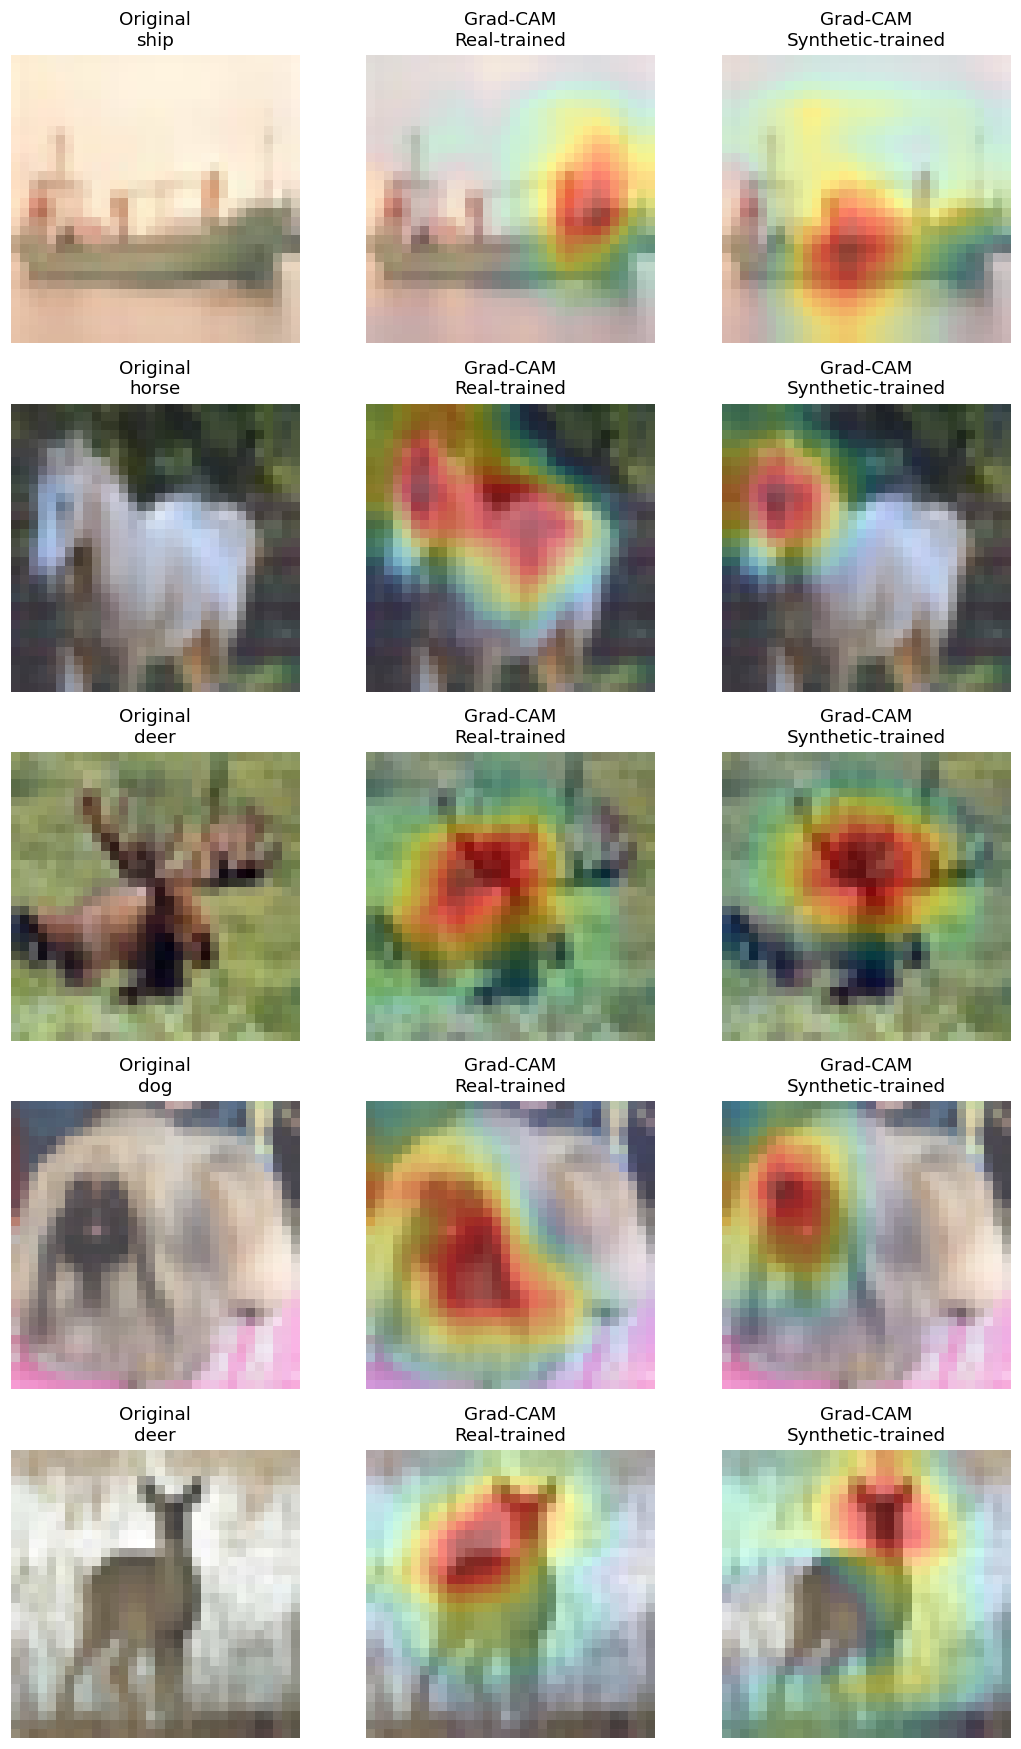

In [15]:
N_EXAMPLES = 5

gradcam_example_indices = test_indices[:N_EXAMPLES]

figure, axes = plt.subplots(
    N_EXAMPLES,
    3,
    figsize=(10, 3.2 * N_EXAMPLES),
)

for row, test_index in enumerate(gradcam_example_indices):
    image = x_test[test_index]
    target_class = int(y_test[test_index])

    heatmap_real = make_gradcam_heatmap(
        image,
        models["real"],
        layers["real"],
        target_class,
    )

    heatmap_synthetic = make_gradcam_heatmap(
        image,
        models["synthetic"],
        layers["synthetic"],
        target_class,
    )

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"Original\n{CIFAR10_CLASSES[target_class]}"
    )

    axes[row, 1].imshow(
        overlay_heatmap(
            image,
            heatmap_real,
        )
    )
    axes[row, 1].set_title(
        "Grad-CAM\nReal-trained"
    )

    axes[row, 2].imshow(
        overlay_heatmap(
            image,
            heatmap_synthetic,
        )
    )
    axes[row, 2].set_title(
        "Grad-CAM\nSynthetic-trained"
    )

    for axis in axes[row]:
        axis.axis("off")

figure.tight_layout()
plt.show()

## 5. Integrated Gradients analysis

Integrated Gradients explanations are computed for both classifiers on the same
CASE A images used for Grad-CAM. Agreement between the two models is evaluated
using Pearson correlation and Top-20% IoU, while explanation faithfulness is
assessed using deletion and insertion AUC.


In [16]:
def select_jointly_correct_images(x_test, y_test, model_real, model_synthetic):
    rng = np.random.default_rng(SEED)
    selected_indices = []
 
    for class_id, class_name in enumerate(CIFAR10_CLASSES):
        class_indices = np.where(y_test == class_id)[0]
        candidate_count = min(IMAGES_PER_CLASS, len(class_indices))
        candidates = rng.choice(
            class_indices,
            size=candidate_count,
            replace=False,
        )
 
        predictions_real = np.argmax(
            model_real.predict(x_test[candidates], batch_size=256, verbose=0),
            axis=1,
        )
        predictions_synthetic = np.argmax(
            model_synthetic.predict(x_test[candidates], batch_size=256, verbose=0),
            axis=1,
        )
        valid = (
            (predictions_real == y_test[candidates])
            & (predictions_synthetic == y_test[candidates])
        )
        selected = candidates[valid]
        selected_indices.extend(selected.tolist())
        print(f"{class_name:10s}: {len(selected)} correctly classified images")
 
    rng.shuffle(selected_indices)
    return np.asarray(selected_indices, dtype=int)
 
 
def save_ig_figure(output_path, image, true_class, ig_real, ig_synthetic):
    real_map = saliency_to_2d(ig_real)
    synthetic_map = saliency_to_2d(ig_synthetic)
    vmax = np.percentile(
        np.concatenate([real_map.reshape(-1), synthetic_map.reshape(-1)]),
        99,
    )
    if vmax == 0:
        vmax = 1e-8
 
    figure, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"Original\nClass: {CIFAR10_CLASSES[true_class]}")
    axes[1].imshow(real_map, cmap="magma", vmin=0, vmax=vmax)
    axes[1].set_title("Integrated Gradients\nReal-trained")
    axes[2].imshow(synthetic_map, cmap="magma", vmin=0, vmax=vmax)
    axes[2].set_title("Integrated Gradients\nSynthetic-trained")
 
    for axis in axes:
        axis.axis("off")
 
    figure.tight_layout()
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(figure)
 
 
def build_summary(rows):
    metric_names = (

        "ig_pearson_correlation",

        "ig_top20_iou",

        "real_deletion_auc",

        "synthetic_deletion_auc",

        "real_insertion_auc",

        "synthetic_insertion_auc",

    )
    groups = [("all", rows)]
    groups.extend(
        (
            class_name,
            [row for row in rows if row["class_name"] == class_name],
        )
        for class_name in CIFAR10_CLASSES
    )
 
    summary = []
    for group_name, group_rows in groups:
        if not group_rows:
            continue
        for metric_name in metric_names:
            values = np.asarray(
                [float(row[metric_name]) for row in group_rows],
                dtype=float,
            )
            summary.append(
                {
                    "group": group_name,
                    "metric": metric_name,
                    "count": len(group_rows),
                    "mean": float(np.nanmean(values)),
                    "std": float(np.nanstd(values)),
                }
            )
    return summary

In [17]:
IG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if RAW_IG_PATH.exists() and not FORCE_RECOMPUTE:
    with np.load(RAW_IG_PATH) as saved_ig:
        explanations_real = saved_ig["explanations_real"]
        explanations_synthetic = saved_ig["explanations_synthetic"]
        selected_images = saved_ig["selected_images"]
        selected_labels = saved_ig["selected_labels"]
        selected_indices = saved_ig["selected_indices"]
    print("IG explanations loaded from:", RAW_IG_PATH)
else:
    selected_indices = test_indices.copy()
    selected_images = x_test[selected_indices]
    selected_labels = y_test[selected_indices]
    targets = tf.one_hot(selected_labels, depth=len(CIFAR10_CLASSES))

    ig_real_explainer = IntegratedGradients(
        models["real"],
        steps=IG_STEPS,
        baseline_value=0.0,
    )
    ig_synthetic_explainer = IntegratedGradients(
        models["synthetic"],
        steps=IG_STEPS,
        baseline_value=0.0,
    )

    print("Computing Integrated Gradients real-trained...")
    explanations_real = ig_real_explainer.explain(
        selected_images, targets
    ).numpy()
    print("Computing Integrated Gradients synthetic-trained...")
    explanations_synthetic = ig_synthetic_explainer.explain(
        selected_images, targets
    ).numpy()

    np.savez(
        RAW_IG_PATH,
        explanations_real=explanations_real,
        explanations_synthetic=explanations_synthetic,
        selected_images=selected_images,
        selected_labels=selected_labels,
        selected_indices=selected_indices,
    )
    print("IG explanations saved to:", RAW_IG_PATH)

# Saved explanations must refer to the CASE A images, in the same order:
# the metrics cell pairs images and maps by position.
assert np.array_equal(selected_indices, test_indices), (
    "Saved IG explanations do not match the CASE A indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)
print("IG explanations:", explanations_real.shape, explanations_synthetic.shape)

IG explanations loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/integrated_gradients/integrated_gradients_raw.npz
IG explanations: (1000, 32, 32, 1) (1000, 32, 32, 1)


In [18]:
if METRICS_CSV.exists() and not FORCE_RECOMPUTE:
    ig_rows = pd.read_csv(METRICS_CSV).to_dict("records")
    print("Per-image IG metrics loaded from:", METRICS_CSV)
else:
    ig_rows = []
    for row_id, test_index in enumerate(selected_indices):
        image = selected_images[row_id]
        target_class = int(selected_labels[row_id])
        ig_real_image = explanations_real[row_id]
        ig_synthetic_image = explanations_synthetic[row_id]

        real_deletion, real_insertion = deletion_insertion_auc(
            models["real"], image, ig_real_image, target_class
        )
        synthetic_deletion, synthetic_insertion = deletion_insertion_auc(
            models["synthetic"], image, ig_synthetic_image, target_class
        )

        class_output_dir = IG_OUTPUT_DIR / (
            f"{target_class}_{CIFAR10_CLASSES[target_class]}"
        )
        class_output_dir.mkdir(parents=True, exist_ok=True)
        save_ig_figure(
            class_output_dir / f"integrated_gradients_index_{test_index}.png",
            image,
            target_class,
            ig_real_image,
            ig_synthetic_image,
        )

        ig_rows.append({
            "test_index": int(test_index),
            "class_id": target_class,
            "class_name": CIFAR10_CLASSES[target_class],
            "ig_pearson_correlation": pearson_correlation(
                ig_real_image, ig_synthetic_image
            ),
            "ig_top20_iou": top_fraction_iou(
                ig_real_image, ig_synthetic_image
            ),
            "real_deletion_auc": real_deletion,
            "synthetic_deletion_auc": synthetic_deletion,
            "real_insertion_auc": real_insertion,
            "synthetic_insertion_auc": synthetic_insertion,
        })

        if (row_id + 1) % 50 == 0 or row_id + 1 == len(selected_indices):
            print(f"IG metrics: {row_id + 1}/{len(selected_indices)}")

    save_rows(METRICS_CSV, ig_rows)
    print("Per-image IG metrics saved to:", METRICS_CSV)

# Saved metrics must refer to exactly the CASE A images selected above.
assert sorted(row["test_index"] for row in ig_rows) == sorted(test_indices.tolist()), (
    "Saved IG metrics do not match the CASE A indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

Per-image IG metrics loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/integrated_gradients/integrated_gradients_metrics.csv


In [19]:
# Integrated Gradients results

ig_summary = build_summary(ig_rows)

save_rows(SUMMARY_CSV, ig_summary)

display(pd.DataFrame(ig_summary).head(20))

print("Output Integrated Gradients:", IG_OUTPUT_DIR)
print("Summary saved to:", SUMMARY_CSV)

,group,metric,count,mean,std
0,all,ig_pearson_correlation,1000,0.167861,0.072900
1,all,ig_top20_iou,1000,0.184786,0.029951
2,all,real_deletion_auc,1000,0.310258,0.221709
3,all,synthetic_deletion_auc,1000,0.214197,0.234999
4,all,real_insertion_auc,1000,0.315213,0.231875
5,all,synthetic_insertion_auc,1000,0.232819,0.259868
6,airplane,ig_pearson_correlation,100,0.144772,0.068653
7,airplane,ig_top20_iou,100,0.175518,0.023431
8,airplane,real_deletion_auc,100,0.364406,0.120539
9,airplane,synthetic_deletion_auc,100,0.294108,0.140934


Output Integrated Gradients: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/integrated_gradients
Summary saved to: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/integrated_gradients/integrated_gradients_summary_metrics.csv


### Representative Integrated Gradients explanations

The same type of comparison is shown for Integrated Gradients, highlighting
the spatial evidence attributed to the true class by the two classifiers.

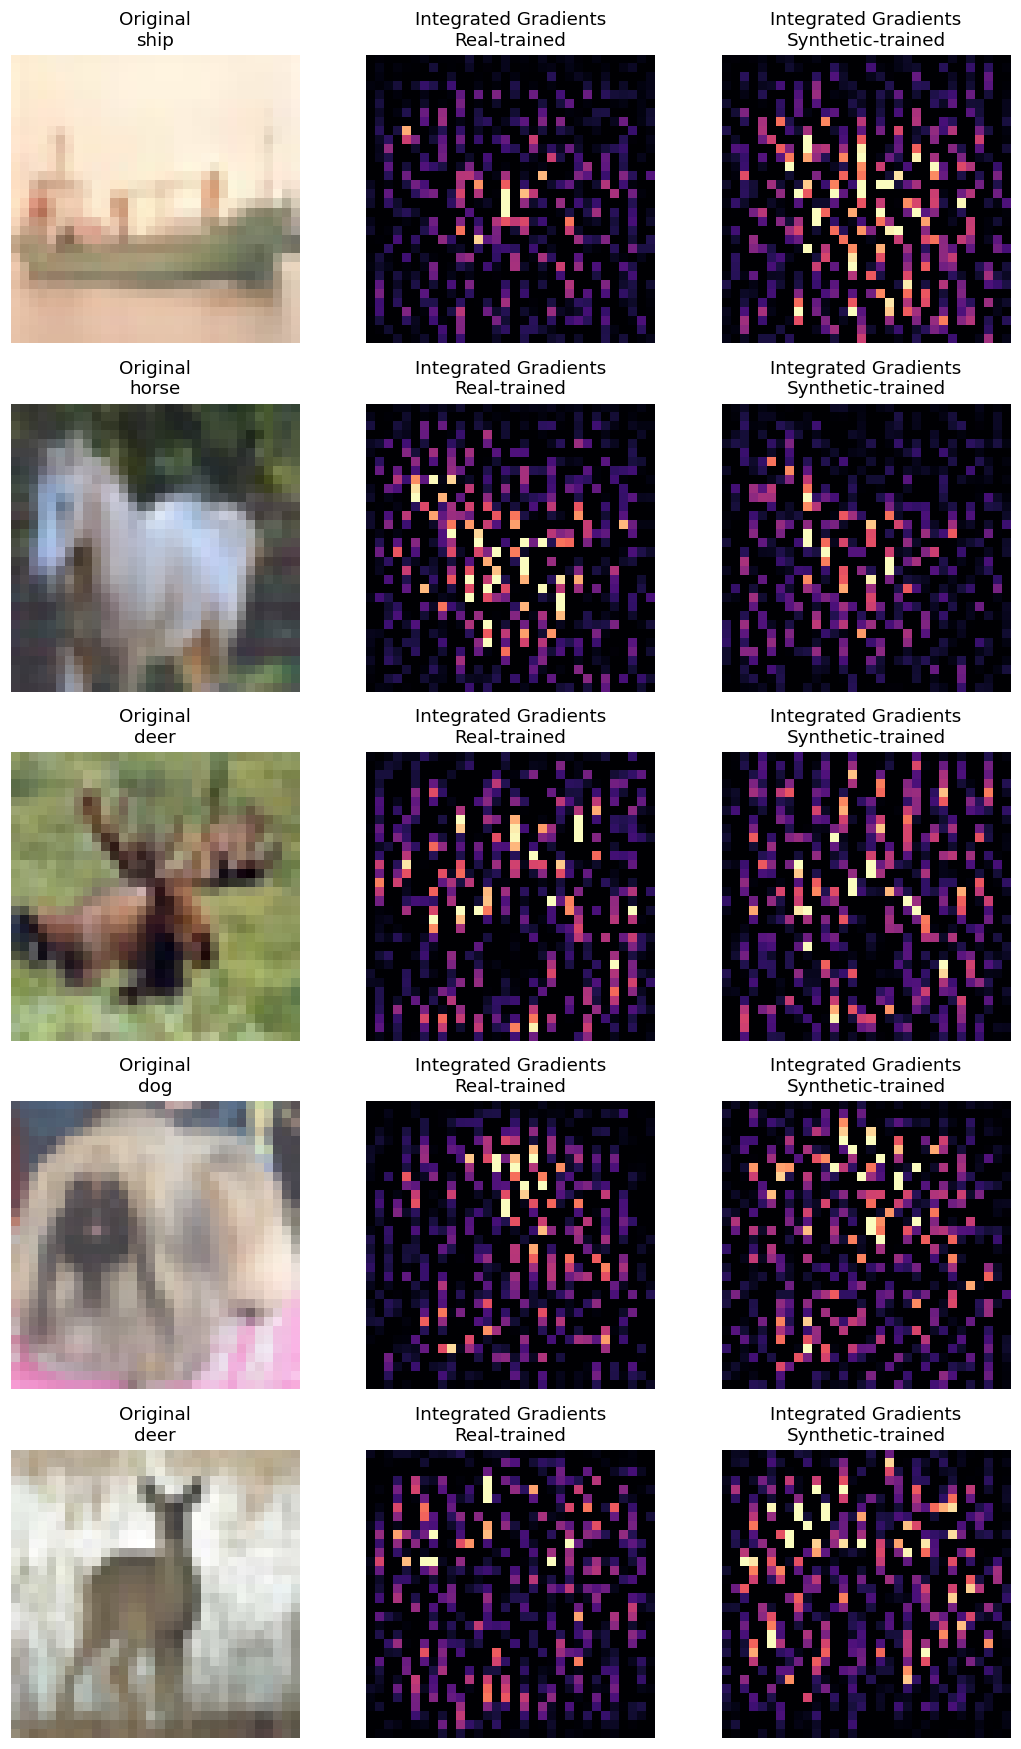

In [20]:
N_EXAMPLES = 5

ig_example_positions = range(
    min(N_EXAMPLES, len(selected_indices))
)

figure, axes = plt.subplots(
    len(list(ig_example_positions)),
    3,
    figsize=(10, 3.2 * min(N_EXAMPLES, len(selected_indices))),
)

for row, position in enumerate(
    range(min(N_EXAMPLES, len(selected_indices)))
):
    test_index = selected_indices[position]
    image = selected_images[position]
    target_class = int(selected_labels[position])

    ig_real_map = saliency_to_2d(
        explanations_real[position]
    )

    ig_synthetic_map = saliency_to_2d(
        explanations_synthetic[position]
    )

    vmax = np.percentile(
        np.concatenate([
            ig_real_map.reshape(-1),
            ig_synthetic_map.reshape(-1),
        ]),
        99,
    )

    if vmax == 0:
        vmax = 1e-8

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"Original\n{CIFAR10_CLASSES[target_class]}"
    )

    axes[row, 1].imshow(
        ig_real_map,
        cmap="magma",
        vmin=0,
        vmax=vmax,
    )
    axes[row, 1].set_title(
        "Integrated Gradients\nReal-trained"
    )

    axes[row, 2].imshow(
        ig_synthetic_map,
        cmap="magma",
        vmin=0,
        vmax=vmax,
    )
    axes[row, 2].set_title(
        "Integrated Gradients\nSynthetic-trained"
    )

    for axis in axes[row]:
        axis.axis("off")

figure.tight_layout()
plt.show()

## 6. LIME analysis — CASE A

LIME explanations are computed for the true class for both classifiers using
the same CASE A images and a shared superpixel segmentation.

Agreement between the real-trained and synthetic-trained explanations is
evaluated using the overlap of their top positive regions.

In [21]:
import warnings
from tqdm import TqdmWarning

# tqdm warns once that ipywidgets is missing: harmless, text bars would be used.
warnings.filterwarnings("ignore", category=TqdmWarning)

from lime import lime_image
from skimage.segmentation import slic, mark_boundaries

# lime 0.2.0.1 draws one tqdm bar per explanation (400 here) and has no option
# to turn it off: replace its module-level tqdm with a pass-through.
lime_image.tqdm = lambda iterable, *args, **kwargs: iterable

LIME_CASE_A_DIR.mkdir(parents=True, exist_ok=True)
LIME_CASE_A_VISUALS_DIR.mkdir(parents=True, exist_ok=True)

LIME_IMAGES_PER_CLASS = 20
LIME_NUM_SAMPLES = 1000
LIME_TOP_K = 5
LIME_N_SEGMENTS = 20

lime_explainer = lime_image.LimeImageExplainer(
    random_state=SEED
)


def lime_predict_fn(model):
    def predict(images):
        images = np.asarray(images, dtype=np.float32)
        return model.predict(
            images,
            batch_size=256,
            verbose=0,
        )
    return predict


def shared_segmentation(image):
    return slic(
        image,
        n_segments=LIME_N_SEGMENTS,
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=-1,
    )


def get_positive_lime_regions(
    explanation,
    target_class,
    top_k=LIME_TOP_K,
):
    weighted_regions = explanation.local_exp[target_class]

    positive_regions = [
        (region_id, weight)
        for region_id, weight in weighted_regions
        if weight > 0
    ]

    positive_regions.sort(
        key=lambda item: item[1],
        reverse=True,
    )

    return [
        region_id
        for region_id, _ in positive_regions[:top_k]
    ]


def lime_region_mask(segments, region_ids):
    return np.isin(
        segments,
        region_ids,
    )


def jaccard_masks(first_mask, second_mask):
    intersection = np.logical_and(
        first_mask,
        second_mask,
    ).sum()

    union = np.logical_or(
        first_mask,
        second_mask,
    ).sum()

    if union == 0:
        return np.nan

    return float(intersection / union)


def save_case_a_lime_figure(
    path,
    image,
    real_mask,
    synthetic_mask,
    class_name,
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(10, 3.5),
    )

    axes[0].imshow(image)
    axes[0].set_title(
        f"Original\nTrue: {class_name}"
    )

    axes[1].imshow(
        mark_boundaries(
            image,
            real_mask.astype(int),
        )
    )
    axes[1].imshow(
        real_mask,
        cmap="Reds",
        alpha=0.30,
    )
    axes[1].set_title(
        "LIME\nReal-trained"
    )

    axes[2].imshow(
        mark_boundaries(
            image,
            synthetic_mask.astype(int),
        )
    )
    axes[2].imshow(
        synthetic_mask,
        cmap="Reds",
        alpha=0.30,
    )
    axes[2].set_title(
        "LIME\nSynthetic-trained"
    )

    for axis in axes:
        axis.axis("off")

    figure.tight_layout()

    figure.savefig(
        path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.close(figure)


rng = np.random.default_rng(SEED)

lime_indices = []

for class_id in range(len(CIFAR10_CLASSES)):
    class_indices = [
        idx
        for idx in test_indices
        if int(y_test[idx]) == class_id
    ]

    sample_size = min(
        LIME_IMAGES_PER_CLASS,
        len(class_indices),
    )

    selected = rng.choice(
        class_indices,
        size=sample_size,
        replace=False,
    )

    lime_indices.extend(selected.tolist())

rng.shuffle(lime_indices)
lime_indices = np.asarray(lime_indices, dtype=int)

print("Total LIME CASE A images:", len(lime_indices))


if LIME_PER_IMAGE_CSV.exists() and not FORCE_RECOMPUTE:
    lime_case_a_df = pd.read_csv(LIME_PER_IMAGE_CSV)
    print("LIME CASE A results loaded from:", LIME_PER_IMAGE_CSV)
else:
    lime_case_a_rows = []

    for processed_count, test_index in enumerate(lime_indices, start=1):
        image = x_test[test_index]
        true_class = int(y_test[test_index])

        segments = shared_segmentation(image)
        segmentation_fn = lambda _: segments

        explanation_real = lime_explainer.explain_instance(
            image,
            lime_predict_fn(models["real"]),
            labels=(true_class,),
            num_samples=LIME_NUM_SAMPLES,
            segmentation_fn=segmentation_fn,
            hide_color=CIFAR10_MEAN,
        )
        explanation_synthetic = lime_explainer.explain_instance(
            image,
            lime_predict_fn(models["synthetic"]),
            labels=(true_class,),
            num_samples=LIME_NUM_SAMPLES,
            segmentation_fn=segmentation_fn,
            hide_color=CIFAR10_MEAN,
        )

        real_regions = get_positive_lime_regions(explanation_real, true_class)
        synthetic_regions = get_positive_lime_regions(explanation_synthetic, true_class)
        real_mask = lime_region_mask(segments, real_regions)
        synthetic_mask = lime_region_mask(segments, synthetic_regions)

        lime_case_a_rows.append({
            "test_index": int(test_index),
            "class_id": true_class,
            "class_name": CIFAR10_CLASSES[true_class],
            "lime_top5_jaccard": jaccard_masks(real_mask, synthetic_mask),
        })

        class_dir = LIME_CASE_A_VISUALS_DIR / f"{true_class}_{CIFAR10_CLASSES[true_class]}"
        class_dir.mkdir(parents=True, exist_ok=True)
        save_case_a_lime_figure(
            class_dir / f"lime_index_{test_index}.png",
            image,
            real_mask,
            synthetic_mask,
            CIFAR10_CLASSES[true_class],
        )

        if processed_count % 25 == 0 or processed_count == len(lime_indices):
            print(f"LIME CASE A: {processed_count}/{len(lime_indices)}")

    lime_case_a_df = pd.DataFrame(lime_case_a_rows)
    lime_case_a_df.to_csv(LIME_PER_IMAGE_CSV, index=False)
    print("LIME CASE A results saved to:", LIME_PER_IMAGE_CSV)

# Same list-of-dicts view in both branches: the examples cell reads it.
lime_case_a_rows = lime_case_a_df.to_dict("records")

# Saved results must refer to the LIME images selected above, in the same order.
assert np.array_equal(lime_case_a_df["test_index"].to_numpy(), lime_indices), (
    "Saved LIME results do not match the LIME CASE A indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

lime_case_a_summary = (
    lime_case_a_df
    .groupby("class_name")
    ["lime_top5_jaccard"]
    .agg(["count", "mean", "std"])
    .reset_index()
)

overall_row = pd.DataFrame({
    "class_name": ["all"],
    "count": [len(lime_case_a_df)],
    "mean": [
        lime_case_a_df[
            "lime_top5_jaccard"
        ].mean()
    ],
    "std": [
        lime_case_a_df[
            "lime_top5_jaccard"
        ].std()
    ],
})

lime_case_a_summary = pd.concat(
    [overall_row, lime_case_a_summary],
    ignore_index=True,
)

lime_case_a_summary.to_csv(
    LIME_CASE_A_DIR / "lime_caseA_summary.csv",
    index=False,
)

display(lime_case_a_summary)

print(
    "Output LIME CASE A:",
    LIME_CASE_A_DIR,
)

Total LIME CASE A images: 200
LIME CASE A: 25/200
LIME CASE A: 50/200
LIME CASE A: 75/200
LIME CASE A: 100/200
LIME CASE A: 125/200
LIME CASE A: 150/200
LIME CASE A: 175/200
LIME CASE A: 200/200
LIME CASE A results saved to: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/lime/lime_caseA_per_image.csv


,class_name,count,mean,std
0,all,200,0.387622,0.209272
1,airplane,20,0.300319,0.217843
2,automobile,20,0.463256,0.275158
3,bird,20,0.308165,0.215582
4,cat,20,0.308668,0.153387
5,deer,20,0.341641,0.166166
6,dog,20,0.429139,0.163308
7,frog,20,0.357975,0.177375
8,horse,20,0.429444,0.211496
9,ship,20,0.467177,0.219611


Output LIME CASE A: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseA/lime


### Representative LIME explanations

Representative examples are shown to compare the positively supporting image regions identified by LIME for the two classifiers on 5 random images.

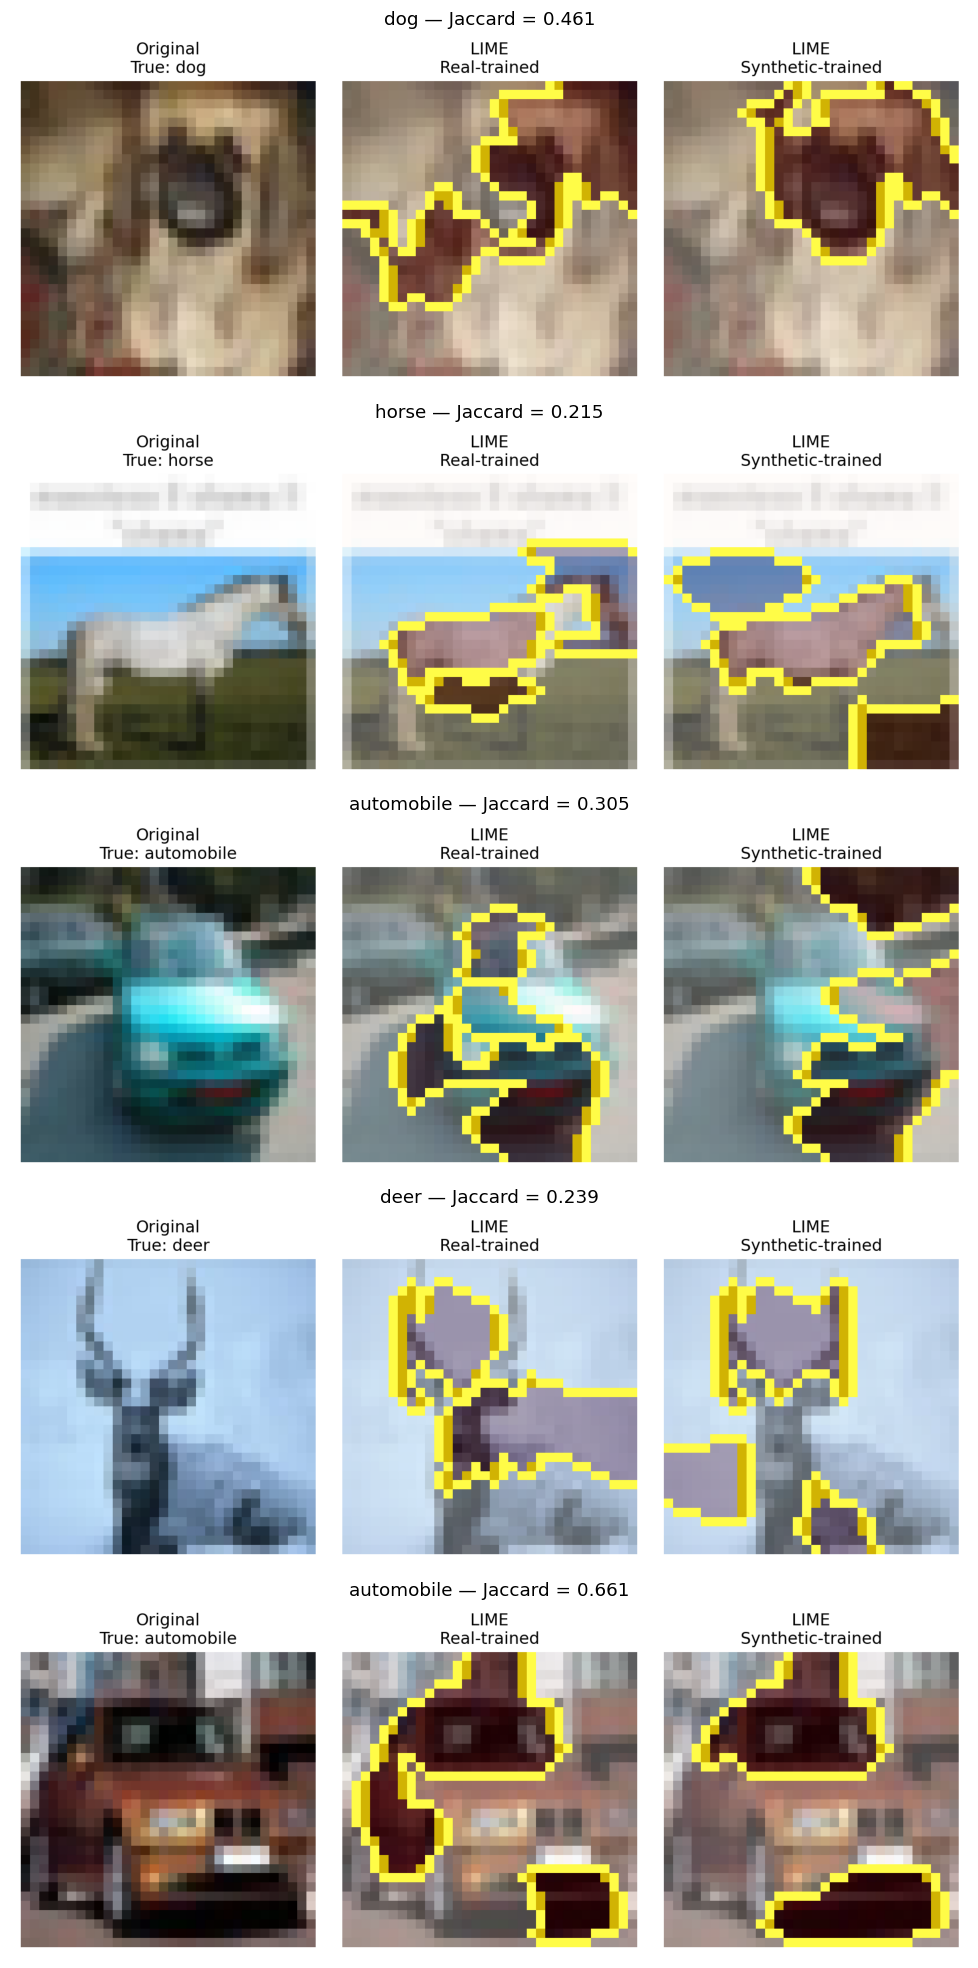

In [22]:
N_EXAMPLES = 5

# Show the figures saved by the LIME loop: recomputing LIME here would draw new
# random perturbations and give masks different from the saved metrics.
figure, axes = plt.subplots(N_EXAMPLES, 1, figsize=(12, 3.6 * N_EXAMPLES))

for axis, result in zip(axes, lime_case_a_rows[:N_EXAMPLES]):
    class_id = int(result["class_id"])
    class_name = result["class_name"]
    image_path = (
        LIME_CASE_A_VISUALS_DIR
        / f"{class_id}_{class_name}"
        / f"lime_index_{int(result['test_index'])}.png"
    )
    axis.imshow(plt.imread(image_path))
    axis.set_title(f"{class_name} — Jaccard = {result['lime_top5_jaccard']:.3f}")
    axis.axis("off")

figure.tight_layout()
plt.show()


The following examples show the CASE A images with the highest agreement between the real-trained and synthetic-trained LIME explanations, measured by the Top-5 superpixel Jaccard overlap.

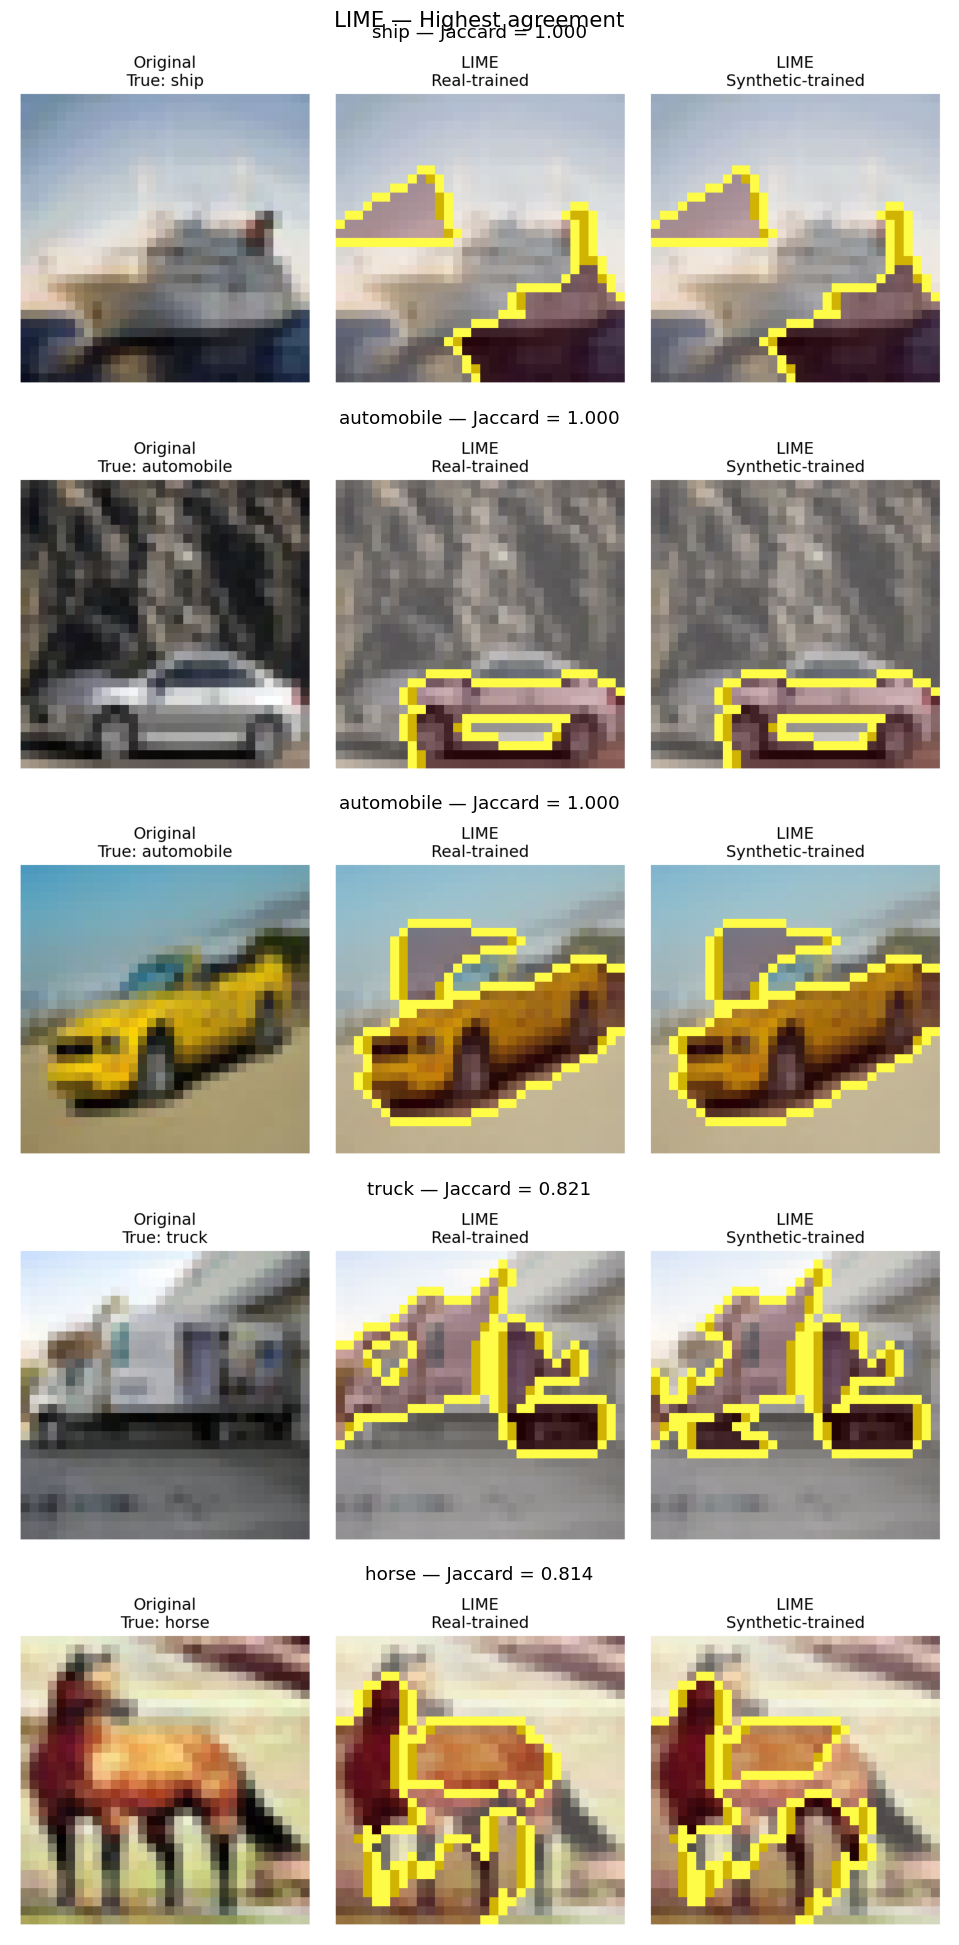

In [23]:
high_agreement = (
    lime_case_a_df
    .sort_values(
        "lime_top5_jaccard",
        ascending=False,
    )
    .head(5)
)

figure, axes = plt.subplots(5, 1, figsize=(12, 18))

for axis, (_, row) in zip(axes, high_agreement.iterrows()):
    test_index = int(row["test_index"])
    class_id = int(row["class_id"])
    class_name = row["class_name"]

    image_path = (
        LIME_CASE_A_VISUALS_DIR
        / f"{class_id}_{class_name}"
        / f"lime_index_{test_index}.png"
    )

    axis.imshow(plt.imread(image_path))
    axis.set_title(
        f"{class_name} — Jaccard = {row['lime_top5_jaccard']:.3f}"
    )
    axis.axis("off")

figure.suptitle("LIME — Highest agreement", fontsize=14)
figure.tight_layout()
plt.show()